# 评分卡建模报告 - hscredit版

本示例演示使用hscredit库进行完整的评分卡建模流程，参考scorecardpipeline的scorecard_samples.ipynb样例。

**数据集**: German Credit Data (德国信贷数据集)
**样本数**: 1000
**特征数**: 20
**目标变量**: class (0=好客户, 1=坏客户)

## 建模流程
1. 数据加载与探索
2. 数据预处理
3. 特征筛选
4. 最优分箱
5. WOE编码
6. 逐步回归筛选
7. 逻辑回归模型训练
8. 评分卡生成
9. 模型评估
10. Excel报告生成
11. PMML导出

## 1. 环境初始化

In [1]:
# 设置路径
import sys
sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')

# 初始化环境
from hscredit.utils import init_setting
init_setting(seed=42)
print('环境初始化完成！')

环境初始化完成！


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
from datetime import datetime

# hscredit核心模块
from hscredit.core.binning import OptimalBinning
from hscredit.core.selectors import (
    NullSelector, VarianceSelector, ModeSelector,
    CorrSelector, IVSelector, StepwiseSelector
)
from hscredit.core.models import LogisticRegression, ScoreCard
from hscredit.core.metrics import KS, AUC
from hscredit.core.viz import bin_plot, corr_plot, ks_plot, hist_plot

# 报告生成模块
from hscredit.report import feature_bin_stats, ExcelWriter, dataframe2excel

# 数据集加载
from hscredit.utils.datasets import germancredit

print('所有模块导入完成！')

所有模块导入完成！


## 2. 数据加载与探索

In [3]:
# 加载German Credit数据集
df = germancredit()
df['class'] = df['class'].astype(int)

print(f'数据集形状: {df.shape}')
print(f'\n列名: {list(df.columns)}')
df.head()

数据集形状: (1000, 21)

列名: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,0
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,1
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,0
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,1


In [4]:
# 数据类型检查
print('数据类型信息:')
print(df.dtypes)

# 缺失值统计
print('\n缺失值统计:')
missing_stats = df.isnull().sum()
print(missing_stats[missing_stats > 0] if missing_stats.sum() > 0 else '无缺失值')

数据类型信息:
checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
class                        int64
dtype: object

缺失值统计:
无缺失值


In [5]:
# 目标变量分布
target = 'class'
print('目标变量分布:')
print(df[target].value_counts(normalize=True))
print(f'\n坏客户率: {df[target].mean():.2%}')

目标变量分布:
class
0   0.7000
1   0.3000
Name: proportion, dtype: float64

坏客户率: 30.00%


## 3. 数据预处理

In [6]:
# 定义特征列表
feature_cols = [col for col in df.columns if col != target]
print(f'特征数量: {len(feature_cols)}')
print(f'特征列表: {feature_cols}')

特征数量: 20
特征列表: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']


In [7]:
# 划分训练集和测试集
train, test = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df[target]
)

print(f'训练集样本数: {len(train)}')
print(f'测试集样本数: {len(test)}')
print(f'\n训练集坏客户率: {train[target].mean():.2%}')
print(f'测试集坏客户率: {test[target].mean():.2%}')

训练集样本数: 700
测试集样本数: 300

训练集坏客户率: 30.00%
测试集坏客户率: 30.00%


## 4. 特征筛选

In [8]:
# 第一步：缺失值筛选
null_selector = NullSelector(threshold=0.3)
null_selector.fit(train[feature_cols], train[target])
features_after_null = null_selector.transform(feature_cols)
print(f'缺失值筛选后特征数: {len(features_after_null)}')

缺失值筛选后特征数: 20


In [9]:
null_selector.transform(feature_cols)

['checking_status',
 'duration',
 'credit_history',
 'purpose',
 'credit_amount',
 'savings_status',
 'employment',
 'installment_commitment',
 'personal_status',
 'other_parties',
 'residence_since',
 'property_magnitude',
 'age',
 'other_payment_plans',
 'housing',
 'existing_credits',
 'job',
 'num_dependents',
 'own_telephone',
 'foreign_worker']

In [10]:
# # 第二步：方差筛选
# variance_selector = VarianceSelector(threshold=0.01)
# variance_selector.fit(train[features_after_null], train[target])
# features_after_variance = variance_selector.transform(features_after_null)
# print(f'方差筛选后特征数: {len(features_after_variance)}')

In [11]:
# 第三步：单一值占比筛选
mode_selector = ModeSelector(threshold=0.95)
mode_selector.fit(train[features_after_null], train[target])
features_after_mode = mode_selector.transform(features_after_null)
print(f'单一值筛选后特征数: {len(features_after_mode)}')

单一值筛选后特征数: 19


In [12]:
# # 第四步：相关性筛选
# corr_selector = CorrSelector(threshold=0.8, method='pearson')
# corr_selector.fit(train[features_after_mode], train[target])
# features_after_corr = corr_selector.transform(features_after_mode)
# print(f'相关性筛选后特征数: {len(features_after_corr)}')

In [13]:
# # 第五步：IV值筛选
# iv_selector = IVSelector(threshold=0.02)
# iv_selector.fit(train[features_after_corr], train[target])
# features_after_iv = iv_selector.transform(features_after_corr)
# print(f'IV值筛选后特征数: {len(features_after_iv)}')
# print(f'\n筛选后的特征: {features_after_iv}')

# # 查看所有特征的IV值
# print('\n\n所有特征的IV值:')
# iv_df = iv_selector.get_iv_interpretation()
# print(iv_df)

## 5. 最优分箱

In [14]:
# 创建分箱器
print('开始最优分箱...')
binner = OptimalBinning(
    max_n_bins=5,
    min_bin_size=0.01,
    method='tree'
)

binner.fit(train[features_after_mode], train[target])
print('最优分箱完成！')

开始最优分箱...
最优分箱完成！


In [15]:
binner.export_rules()

{'checking_status': [],
 'duration': [8.5, 16.5, 34.5, 47.5],
 'credit_history': [],
 'purpose': [],
 'credit_amount': [3444.0, 3913.5, 5297.5, 7760.5],
 'savings_status': [],
 'employment': [],
 'installment_commitment': [1.5, 2.5, 3.5],
 'personal_status': [],
 'other_parties': [],
 'residence_since': [1.5, 2.5, 3.5],
 'property_magnitude': [],
 'age': [25.5, 32.5, 34.5, 52.5],
 'other_payment_plans': [],
 'housing': [],
 'existing_credits': [1.5],
 'job': [],
 'num_dependents': [1.5],
 'own_telephone': []}

In [16]:
# # 查看分箱结果
# print('分箱结果预览：')
# for feature in features_after_mode[:3]:
#     if feature in binner.bin_edges_:
#         print(f'\n{feature}:')
#         print(binner.bin_edges_[feature])

## 6. WOE编码

In [17]:
# 使用分箱后的数据进行WOE编码
from heapq import merge


train_binned = binner.transform(train[features_after_mode], metric='woe')
test_binned = binner.transform(test[features_after_mode], metric='woe')

print(f'WOE编码后训练集形状: {train_binned.shape}')
print(f'WOE编码后测试集形状: {test_binned.shape}')

# 查看WOE编码后的数据
train_binned.head()

WOE编码后训练集形状: (700, 19)
WOE编码后测试集形状: (300, 19)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone
10,0.4152,-0.3126,0.0828,0.1804,-0.1146,0.3018,0.5790,0.1001,0.2461,-0.0060,0.0715,0.0348,0.4553,-0.1746,0.4689,0.0355,-0.0396,-0.0057,0.0442
82,-1.1841,0.1761,0.0828,0.2187,-0.1146,0.0981,-0.0747,0.1001,0.2461,-0.0060,-0.0364,-0.0514,0.4553,-0.1746,0.4689,0.0355,-0.1043,-0.0057,0.0442
827,-1.1841,0.1761,1.1350,0.2187,0.8473,0.3018,-0.0747,-0.2118,-0.1634,-0.0060,-0.0153,0.0348,-0.4156,0.3083,-0.2145,-0.0610,-0.0396,0.0299,0.0442
410,0.4152,0.1761,0.0828,-0.3848,-0.1146,0.3018,-0.1942,0.1495,0.2461,-0.0060,-0.0364,0.0348,0.4553,-0.1746,-0.2145,0.0355,-0.0396,-0.0057,-0.0665
48,-1.1841,-0.3126,-0.6991,0.1804,-0.2136,0.3018,-0.0747,-0.2921,-0.1634,-0.0060,-0.0364,-0.0514,-0.4156,-0.1746,-0.2145,-0.0610,-0.1043,-0.0057,0.0442


## 7. 逐步回归特征筛选

In [18]:
# 使用逐步回归筛选最终入模特征
stepwise = StepwiseSelector(
    direction='both',
    max_features=10,
)

stepwise.fit(train_binned, train[target])
final_features = stepwise.selected_features_
print(f'逐步回归筛选后最终特征数: {len(final_features)}')
print(f'最终特征: {final_features}')

逐步回归筛选后最终特征数: 10
最终特征: ['checking_status', 'credit_amount', 'duration', 'purpose', 'credit_history', 'savings_status', 'employment', 'installment_commitment', 'other_payment_plans', 'personal_status']


## 8. 逻辑回归模型训练

In [ ]:
# 训练逻辑回归模型
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(train_binned[final_features], train[target])
print('逻辑回归模型训练完成！')

逻辑回归模型训练完成！


In [20]:
# 查看模型系数
coef_df = pd.DataFrame({
    '特征': final_features,
    '系数': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])
})
coef_df['绝对系数'] = coef_df['系数'].abs()
coef_df = coef_df.sort_values('绝对系数', ascending=False).drop('绝对系数', axis=1)

print('特征系数（按绝对值排序）：')
print(coef_df)

特征系数（按绝对值排序）：
                       特征     系数  Odds_Ratio
7  installment_commitment 1.2491      3.4873
3                 purpose 1.0548      2.8715
9         personal_status 1.0401      2.8296
1           credit_amount 0.9432      2.5682
2                duration 0.9061      2.4747
0         checking_status 0.8666      2.3789
8     other_payment_plans 0.8461      2.3304
6              employment 0.8029      2.2321
4          credit_history 0.7080      2.0299
5          savings_status 0.7019      2.0177


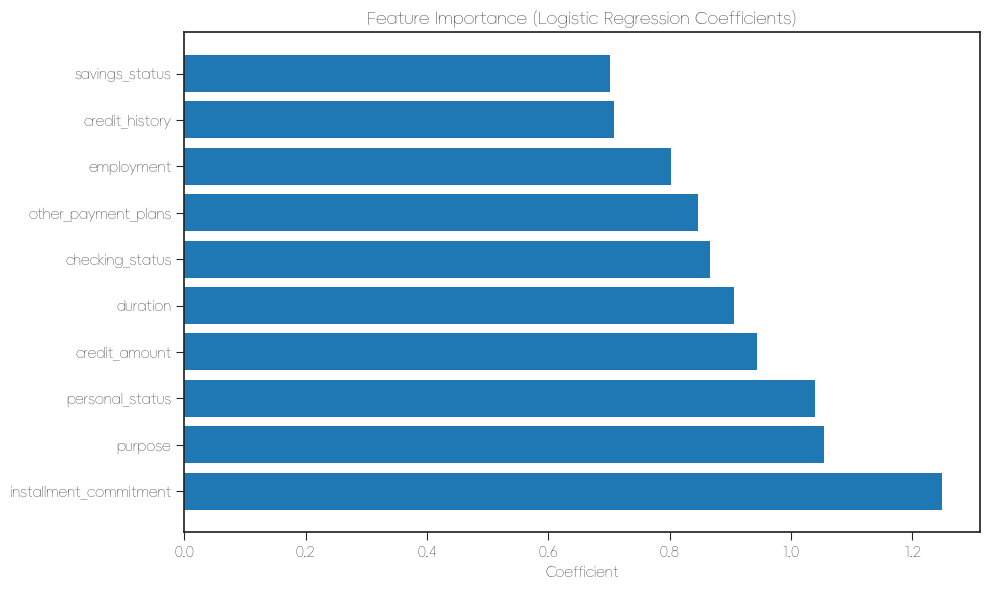

In [21]:
# 绘制特征重要性图
plt.figure(figsize=(10, 6))
plt.barh(coef_df['特征'], coef_df['系数'])
plt.xlabel('Coefficient')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.tight_layout()
plt.show()

## 9. 评分卡模型生成

In [23]:
# 创建评分卡模型
scorecard = ScoreCard(
    binner=binner,
    lr_model=lr_model,
    pdo=50,
    base_score=600,
    base_odds=1/19
)

ScoreCard.fit(train_binned[final_features], train[target])

# 计算评分
train['score'] = scorecard.predict(train[final_features])
test['score'] = scorecard.predict(test[final_features])

print('评分卡模型生成完成！')
print(f'\n训练集分数范围: [{train["score"].min():.2f}, {train["score"].max():.2f}]')
print(f'测试集分数范围: [{test["score"].min():.2f}, {test["score"].max():.2f}]')

TypeError: ScoreCard.fit() missing 1 required positional argument: 'y'

In [ ]:
# 查看评分卡刻度信息
scale_info = scorecard.scorecard_scale()
print('评分卡刻度信息：')
print(scale_info)

In [ ]:
# 查看评分卡分数表
points_table = scorecard.scorecard_points()
print('\n评分卡分数表（前15行）：')
print(points_table.head(15))

## 10. 模型评估

In [ ]:
# 计算训练集和测试集的KS和AUC
train_pred_proba = lr_model.predict_proba(train_binned[final_features])[:, 1]
test_pred_proba = lr_model.predict_proba(test_binned[final_features])[:, 1]

train_ks = KS(train['score'], train[target])
test_ks = KS(test['score'], test[target])

train_auc = AUC(train_pred_proba, train[target])
test_auc = AUC(test_pred_proba, test[target])

print('模型评估指标：')
print(f'训练集 - KS: {train_ks:.4f}, AUC: {train_auc:.4f}')
print(f'测试集 - KS: {test_ks:.4f}, AUC: {test_auc:.4f}')

## 11. 可视化分析

In [ ]:
# 创建报告目录
report_dir = 'model_report'
os.makedirs(report_dir, exist_ok=True)
os.makedirs(f'{report_dir}/bin_plots', exist_ok=True)

print('报告目录创建完成！')

In [ ]:
# 绘制KS曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ks_plot(train['score'], train[target], title='Train Dataset', ax=axes[0])
ks_plot(test['score'], test[target], title='Test Dataset', ax=axes[1])

plt.tight_layout()
plt.savefig(f'{report_dir}/ks_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('KS曲线保存完成！')

In [ ]:
# 绘制分数分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist_plot(train['score'], train[target], title='Train Score Distribution', ax=axes[0])
hist_plot(test['score'], test[target], title='Test Score Distribution', ax=axes[1])

plt.tight_layout()
plt.savefig(f'{report_dir}/score_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print('分数分布图保存完成！')

In [ ]:
# 绘制特征相关性热力图
plt.figure(figsize=(12, 10))
corr_plot(train_binned[final_features], title='Feature Correlation Heatmap', annot=False)
plt.tight_layout()
plt.savefig(f'{report_dir}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('相关性热力图保存完成！')

In [ ]:
# 绘制特征分箱分析图
for i, feature in enumerate(final_features):
    # 生成分箱统计表
    bin_table = feature_bin_stats(
        train,
        feature,
        target=target,
        desc=feature,
        combiner=binner
    )
    
    # 绘制分箱图
    plt.figure(figsize=(10, 6))
    bin_plot(bin_table, desc=feature)
    plt.tight_layout()
    plt.savefig(f'{report_dir}/bin_plots/{feature}_bin.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f'特征分箱图保存完成！共{len(final_features)}个特征')

## 12. Excel报告生成

In [ ]:
# 创建Excel写入器
excel_path = f'{report_dir}/scorecard_report.xlsx'
writer = ExcelWriter()

print('Excel报告生成器初始化完成！')

In [ ]:
# 12.1 汇总信息sheet
worksheet = writer.get_sheet_by_name('汇总信息')
start_row, start_col = 2, 2

# 模型基本信息
model_info = pd.DataFrame([
    ['模型名称', 'German Credit评分卡模型'],
    ['训练样本数', len(train)],
    ['测试样本数', len(test)],
    ['入模特征数', len(final_features)],
    ['训练集KS', f'{train_ks:.4f}'],
    ['测试集KS', f'{test_ks:.4f}'],
    ['训练集AUC', f'{train_auc:.4f}'],
    ['测试集AUC', f'{test_auc:.4f}'],
    ['生成时间', datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
], columns=['指标', '数值'])

end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='模型基本信息', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, model_info, (end_row, start_col), header=False, index=False)

# 样本分布
sample_dist = pd.DataFrame([
    ['训练集坏客户率', f'{train[target].mean():.2%}'],
    ['测试集坏客户率', f'{test[target].mean():.2%}'],
    ['训练集好客户数', (train[target] == 0).sum()],
    ['训练集坏客户数', (train[target] == 1).sum()],
    ['测试集好客户数', (test[target] == 0).sum()],
    ['测试集坏客户数', (test[target] == 1).sum()]
], columns=['指标', '数值'])

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='样本分布', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, sample_dist, (end_row, start_col), header=False, index=False)

print('汇总信息sheet生成完成！')

In [ ]:
# 12.2 逻辑回归拟合结果sheet
worksheet = writer.get_sheet_by_name('逻辑回归拟合结果')
start_row, start_col = 2, 2

# 模型系数
end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='模型系数', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, coef_df, (end_row, start_col))

# 特征重要性（基于系数绝对值）
importance_df = pd.DataFrame({
    '特征': coef_df['特征'].values,
    '重要性': coef_df['系数'].abs().values
}).sort_values('重要性', ascending=False)

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='特征重要性排序', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, importance_df, (end_row, start_col))

print('逻辑回归拟合结果sheet生成完成！')

In [ ]:
# 12.3 评分卡结果sheet
worksheet = writer.get_sheet_by_name('评分卡结果')
start_row, start_col = 2, 2

# 评分卡刻度
end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='评分卡刻度', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, scale_info, (end_row, start_col))

# 评分卡分数表
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='评分卡分数表', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, points_table, (end_row, start_col), merge_column='变量名称')

# 分数统计
score_stats = pd.DataFrame([
    ['训练集最小值', train['score'].min()],
    ['训练集最大值', train['score'].max()],
    ['训练集平均值', train['score'].mean()],
    ['训练集中位数', train['score'].median()],
    ['测试集最小值', test['score'].min()],
    ['测试集最大值', test['score'].max()],
    ['测试集平均值', test['score'].mean()],
    ['测试集中位数', test['score'].median()]
], columns=['统计项', '数值'])

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='分数统计', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, score_stats, (end_row, start_col), header=False, index=False)

print('评分卡结果sheet生成完成！')

In [ ]:
# 12.4 模型评估可视化sheet
worksheet = writer.get_sheet_by_name('模型评估可视化')
start_row, start_col = 2, 2

# KS曲线
end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='KS曲线', style='header')
end_row, end_col = writer.insert_pic2sheet(worksheet, f'{report_dir}/ks_plot.png', (end_row, start_col), figsize=(800, 350))

# 分数分布
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 1, start_col), value='分数分布', style='header')
end_row, end_col = writer.insert_pic2sheet(worksheet, f'{report_dir}/score_hist.png', (end_row, start_col), figsize=(800, 350))

# 相关性热力图
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 1, start_col), value='特征相关性热力图', style='header')
end_row, end_col = writer.insert_pic2sheet(worksheet, f'{report_dir}/correlation_heatmap.png', (end_row, start_col), figsize=(700, 500))

print('模型评估可视化sheet生成完成！')

In [ ]:
# 12.5 特征分箱分析sheet
worksheet = writer.get_sheet_by_name('特征分箱分析')
start_row, start_col = 2, 2

# 为每个特征插入分箱统计表和可视化
for i, feature in enumerate(final_features):
    # 插入标题
    end_row, end_col = writer.insert_value2sheet(
        worksheet, (start_row, start_col),
        value=f'{i+1}. {feature} 分箱分析',
        style='header'
    )
    
    # 插入分箱统计表
    bin_table = feature_bin_stats(
        train,
        feature,
        target=target,
        desc=feature,
        combiner=binner
    )
    
    end_row, end_col = writer.insert_df2sheet(
        worksheet, bin_table, (end_row, start_col),
        merge_column='分箱标签'
    )
    
    # 插入分箱图
    bin_plot_path = f'{report_dir}/bin_plots/{feature}_bin.png'
    if os.path.exists(bin_plot_path):
        end_row, end_col = writer.insert_pic2sheet(
            worksheet, bin_plot_path, (end_row + 1, start_col),
            figsize=(700, 400)
        )
    
    start_row = end_row + 1

print(f'特征分箱分析sheet生成完成！共{len(final_features)}个特征')

In [ ]:
# 12.6 保存Excel报告
writer.save(excel_path)
print(f'Excel报告保存完成！路径: {excel_path}')

## 13. PMML模型导出

In [ ]:
# 导出PMML文件
pmml_path = f'{report_dir}/scorecard.pmml'
scorecard.export_pmml(
    pmml_path,
    feature_names=final_features,
    target_name=target
)

print(f'PMML模型导出完成！路径: {pmml_path}')

In [ ]:
# 验证PMML预测结果（如果安装了pypmml）
try:
    from pypmml import Model
    
    # 加载PMML模型
    pmml_model = Model.load(pmml_path)
    
    # 准备测试数据
    test_sample = test[final_features].head(10).copy()
    
    # PMML预测
    pmml_predictions = []
    for _, row in test_sample.iterrows():
        result = pmml_model.predict(row.to_dict())
        # 提取预测分数
        if hasattr(result, 'entrySet'):
            result_dict = {entry.getKey(): entry.getValue() for entry in result.entrySet()}
            score = result_dict.get('score', result_dict.get('prediction', 0))
        else:
            score = result.get('score', result.get('prediction', 0))
        pmml_predictions.append(score)
    
    # 本地预测
    local_predictions = scorecard.predict_score(test_sample)
    
    # 对比结果
    comparison = pd.DataFrame({
        'PMML预测': pmml_predictions,
        '本地预测': local_predictions.values,
        '差异': np.array(pmml_predictions) - local_predictions.values
    })
    
    print('PMML预测对比（前10个样本）：')
    print(comparison)
    
    max_diff = np.abs(comparison['差异']).max()
    print(f'\n最大差异: {max_diff:.6f}')
    if max_diff < 0.01:
        print('PMML预测与本地预测一致！')
    else:
        print('警告：PMML预测与本地预测存在较大差异！')
        
except ImportError:
    print('pypmml未安装，跳过PMML预测验证')
except Exception as e:
    print(f'PMML预测验证出错: {e}')

## 14. 总结

In [ ]:
print('='*80)
print('评分卡建模报告生成完成！')
print('='*80)
print(f'\n模型性能：')
print(f'  - 训练集KS: {train_ks:.4f}, AUC: {train_auc:.4f}')
print(f'  - 测试集KS: {test_ks:.4f}, AUC: {test_auc:.4f}')
print(f'\n入模特征数: {len(final_features)}')
print(f'\n生成的文件：')
print(f'  1. Excel报告: {excel_path}')
print(f'  2. PMML模型: {pmml_path}')
print(f'  3. 可视化图表: {report_dir}/')
print('='*80)